# A Revenue Decision Support Tool for Hotel Commercial Strategy - a Machine Learning project

## Table of Contents

1. Dataset Overview
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Machine Learning Models
5. Business Interpretation
6. Booking Rysk Analyzer
7. Limitations and Future Improvements
8. Conclusions

### 1. Dataset Overview

Before proceeding with the analysis, we inspect the structure of the dataset to understand the available variables, their data types, and identify any potential missing values or inconsistencies.

In [84]:
# Libraries
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [85]:
df = pd.read_csv("hotel_bookings.csv")

In [86]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


Once we have our dataset downloaded, we check all the variables and information provided.

In [87]:
df.shape

(119390, 32)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [89]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

The dataset contains 119,390 observations and 32 variables.

Most variables are correctly stored using appropriate data types. However, some variables, such as "agent", "company" and "country" contain missing values that will require further inspection during the data cleaning phase. This however makes sense, since not all reservations will come from an agent or company and it is very likely that guests do not share their country of residence prior to Check In.

We check the duplicated rows.

In [90]:
df.duplicated().sum()

np.int64(31994)

We can identify 31,994 duplicated rows in our dataset. Given the transactional nature of hotel booking data, these duplicates may represent different bookings that share identical characteristics rather than erroneous duplicate records.

Therefore, no duplicate records are removed at this stage. This decision is consistent with the original dataset documentation and will be revisited only if further evidence suggests data quality issues.

We need to examine the distribution of our target column. Understanding the class balance is important, as highly imbalanced datasets may require additional modelling strategies or alternative evaluation metrics.

In [91]:
df["is_canceled"].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

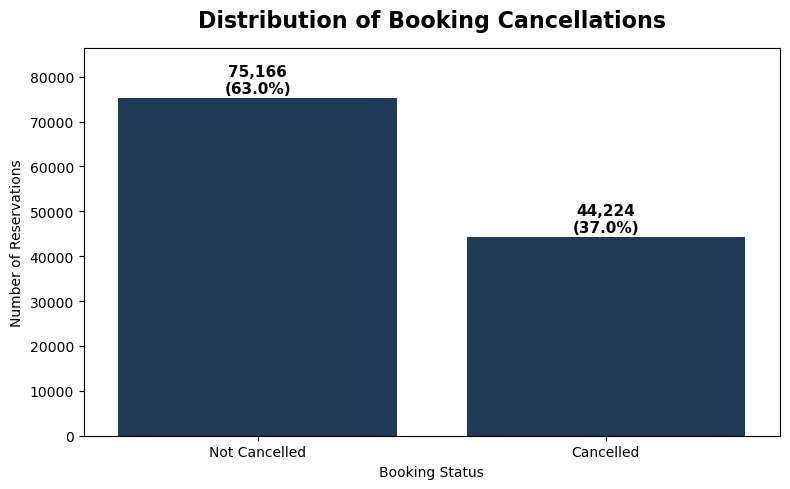

In [ ]:
counts = df["is_canceled"].value_counts().sort_index()
percentages = counts / counts.sum() * 100

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=["Not Cancelled", "Cancelled"],
    y=counts.values,
    color="#2F5D62"
)

plt.title("Distribution of Booking Cancellations",
          fontsize=16,
          fontweight="bold",
          pad=15)

plt.xlabel("Booking Status")
plt.ylabel("Number of Reservations")

plt.ylim(0, counts.max()*1.15)

# Add labels
for i, value in enumerate(counts.values):
    ax.text(
        i,
        value + counts.max()*0.015,
        f"{value:,}\n({percentages.iloc[i]:.1f}%)",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

Approximately 63% of the bookings were not cancelled, while 37% resulted in a cancellation.

Although the dataset shows a moderate class imbalance, both classes are well represented. Therefore, standard classification algorithms can be applied without the need for resampling techniques at this stage.

### 2. Data Cleaning

After completing the initial dataset inspection, we prepare the data for exploratory analysis and predictive modelling.

The cleaning process focuses on missing values, inconsistent data types, potentially invalid records and unusual numerical values. Records are not removed automatically; each cleaning decision is evaluated according to the meaning of the variable and the intended business use.

We create a copy of our dataset prior to cleaning the data.

In [93]:
df_clean = df.copy()

We start to clean the null values.

In [94]:
df.isnull().sum()[df.isnull().sum() > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

Since the variable "children" has only 4 null values, we will replace them with a 0, since most likely these are reservations without children.

In [95]:
df_clean["children"] = df_clean["children"].fillna(0)

In [96]:
df_clean["children"] = df_clean["children"].astype(int)

As we do not know the country for these guests, we will replace it with "Unknown".

In [97]:
df_clean["country"] = df_clean["country"].fillna("Unknown")

Now, "agent" and "company" do contain many null values. For the moment, we will not drop these columns yet, we will replace the null values with a 0, to indicate that these reservations do not have an agent or company for most probably they are individual reservations. 

In [98]:
df_clean["agent"] = df_clean["agent"].fillna(0)
df_clean["company"] = df_clean["company"].fillna(0)

In [99]:
df_clean["agent"] = df_clean["agent"].astype(int)
df_clean["company"] = df_clean["company"].astype(int)

In [100]:
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]

Series([], dtype: int64)

Once null values have been handled, we check the impossible values.

In [101]:
df_clean[
    (df_clean["adults"] == 0) &
     (df_clean["children"] == 0) &
     (df_clean["babies"] == 0)
].shape

(180, 32)

In [102]:
df_clean[
    (df_clean["adults"] == 0) &
     (df_clean["children"] == 0) &
     (df_clean["babies"] == 0)
].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,No Deposit,0,174,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,No Deposit,0,174,0,Transient,0.0,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,No Deposit,38,0,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,No Deposit,308,0,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,No Deposit,308,0,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05


In [103]:
df_clean[
    (df_clean["adults"] == 0) &
    (df_clean["children"] == 0) &
    (df_clean["babies"] == 0)
]["is_canceled"].value_counts()

is_canceled
0    155
1     25
Name: count, dtype: int64

In [104]:
df_clean = df_clean[
    ~(
        (df_clean["adults"] == 0) &
        (df_clean["children"] == 0) &
        (df_clean["babies"] == 0)
    )
].copy()

In [105]:
df_clean.shape

(119210, 32)

A total of 180 bookings showed zero adults, zero children and zero babies. Since these records do not represent a valid hotel stay, they were removed from the analysis to improve data quality and ensure consistency during exploratory analysis and predictive modelling.

In [106]:
df_clean[
    (df_clean["stays_in_weekend_nights"] == 0) &
    (df_clean["stays_in_week_nights"] == 0)
].shape

(645, 32)

We also count with 645 bookings with 0 nights. However, these reservations could be Day Use, so we will not drop any rows here yet.

In [107]:
df_clean["adr"].describe()

count    119210.000000
mean        101.969092
std          50.434007
min          -6.380000
25%          69.500000
50%          94.950000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [108]:
df_clean[df_clean["adr"] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,No Deposit,273,0,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [109]:
df_clean.nlargest(10, "adr")["adr"]

48515     5400.00
111403     510.00
15083      508.00
103912     451.50
13142      450.00
13391      437.00
39155      426.25
39568      402.00
39118      397.38
13323      392.00
Name: adr, dtype: float64

We investigated the negative ADR booking and the highest ADR reservations, in order to have an overview of the dataset. The negative ADR, -6.38€ may be a refund, while the highest one, 5,400, may be a special suite or even. Since they are only 2 rows, we will not drop them for now, eventhough they are considered outliers.

In [110]:
categorical_columns = df_clean.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts(dropna=False).head(15))


hotel
hotel
City Hotel      79163
Resort Hotel    40047
Name: count, dtype: int64

arrival_date_month
arrival_date_month
August       13861
July         12644
May          11780
October      11147
April        11078
June         10929
September    10500
March         9768
February      8052
November      6771
December      6759
January       5921
Name: count, dtype: int64

meal
meal
BB           92236
HB           14458
SC           10549
Undefined     1169
FB             798
Name: count, dtype: int64

country
country
PRT    48483
GBR    12120
FRA    10401
ESP     8560
DEU     7285
ITA     3761
IRL     3374
BEL     2342
BRA     2222
NLD     2103
USA     2093
CHE     1726
CN      1279
AUT     1263
SWE     1020
Name: count, dtype: int64

market_segment
market_segment
Online TA        56408
Offline TA/TO    24182
Groups           19791
Direct           12582
Corporate         5282
Complementary      728
Aviation           235
Undefined            2
Name: count, dtype: int64

distribution

Firstly, we need to understand the Undefined value in meal. Our dataset documentation states: "Undefined/SC – no meal package", so it makes sense we unify both values into one in order to simplify the data.

In [111]:
df_clean["meal"] = df_clean["meal"].replace("Undefined", "SC")

In [112]:
df_clean["meal"].value_counts()

meal
BB    92236
HB    14458
SC    11718
FB      798
Name: count, dtype: int64

We invetigate the Undefined values in "market segment" and "distribution channel"

In [113]:
df_clean[df_clean["market_segment"] =="Undefined"]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,No Deposit,0,0,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,No Deposit,0,0,0,Transient-Party,18.0,0,2,Canceled,2015-08-04


In [114]:
df_clean[df_clean["distribution_channel"] =="Undefined"]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14594,Resort Hotel,0,103,2015,July,28,5,2,3,2,...,No Deposit,0,0,0,Transient,112.7,1,2,Check-Out,2015-07-10
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,No Deposit,0,0,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,...,No Deposit,14,0,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,No Deposit,0,0,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,...,No Deposit,9,0,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


In [115]:
df_clean["market_segment"] = df_clean["market_segment"].replace("Undefined", "Unknown")

df_clean["distribution_channel"] = df_clean["distribution_channel"].replace("Undefined", "Unknown")

In [116]:
df_clean["market_segment"].value_counts()

market_segment
Online TA        56408
Offline TA/TO    24182
Groups           19791
Direct           12582
Corporate         5282
Complementary      728
Aviation           235
Unknown              2
Name: count, dtype: int64

In [117]:
df_clean["distribution_channel"].value_counts()

distribution_channel
TA/TO        97750
Direct       14611
Corporate     6651
GDS            193
Unknown          5
Name: count, dtype: int64

Since the remaining variables in these rows seem valid, we keep these rows but replace Undefined with Unknown, since this information is unknown to us.

In [118]:
df_clean["reservation_status"].value_counts()

reservation_status
Check-Out    75011
Canceled     42993
No-Show       1206
Name: count, dtype: int64

At this point, we are not dropping this variable, however, when we prepare the dataset for the ML model we will need to drop it, since the variable "Canceled" will definitely create data leakage. Most probably, we will need to drop as well "reservation status date", for this also gives information regarding the status of the booking.

**Data Cleaning Summary**

The dataset did not require a lot of cleaning. Missing values were handled according to the business meaning of each variable, invalid guest records were removed, and a small number of categorical values were consolidated based on the official dataset documentation. Extreme ADR values were retained after inspection, as no evidence suggested they represented data quality issues.

### Exploratory Data Analysis (EDA)

**Which booking characteristics are associated with a higher cancellation rate?**

This is the business question we need to answer and we will do so through a series of subquestions. It is important, before building our predictive model, to understand which factor impact on booking cancellations.

#### 1. Understanding Booking Cancellations

This section explores the main booking characteristics related to cancellations.

The objective is to identify patterns that may help Revenue Managers understand customer behaviour before building the predictive model.

**1.1. Does the hotel type influence booking cancellation rates?**

In this dataset we count with two different hotels, a Resort in Algarve and a City Hotel in Lisbon. Comparing cancellation rates across City Hotels and Resort Hotels provides an initial view of customer behaviour and may reveal operational differences relevant for Revenue Management.


In [119]:
hotel_cancel = (
    df_clean.groupby("hotel")["is_canceled"]
    .mean()
    .reset_index()
)

hotel_cancel["is_canceled"] = hotel_cancel["is_canceled"] * 100

hotel_cancel

,hotel,is_canceled
0,City Hotel,41.785935
1,Resort Hotel,27.767373


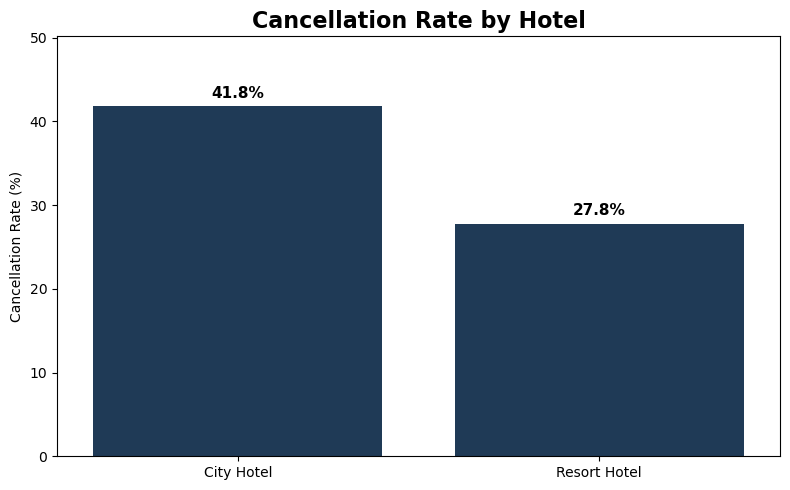

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=hotel_cancel,
    x="hotel",
    y="is_canceled",
    color="#2F5D62"
)

plt.title(
    "Cancellation Rate by Hotel",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(hotel_cancel["is_canceled"]):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(0, hotel_cancel["is_canceled"].max()*1.20)

plt.tight_layout()

plt.show()

**Key Findings**

City Hotels have a higher cancellation rate (41.8%) than Resort Hotels (27.8%). This suggests that hotel type may influence booking cancellations and could be a useful variable for the predictive model.

**1.2. Does the market segment influence booking cancellation rates?**

This analysis explores whether cancellation rates vary across market segments.

In [121]:
market_cancel = (
    df_clean.groupby("market_segment")["is_canceled"]
    .mean()
    .reset_index()
)

market_cancel["is_canceled"] *= 100

market_cancel = market_cancel.sort_values(
    by="is_canceled",
    ascending=False
)

market_plot = market_cancel[market_cancel["market_segment"] != "Unknown"]

market_plot

,market_segment,is_canceled
4,Groups,61.108585
6,Online TA,36.758970
5,Offline TA/TO,34.331321
0,Aviation,22.127660
2,Corporate,18.761833
3,Direct,15.371165
1,Complementary,12.225275


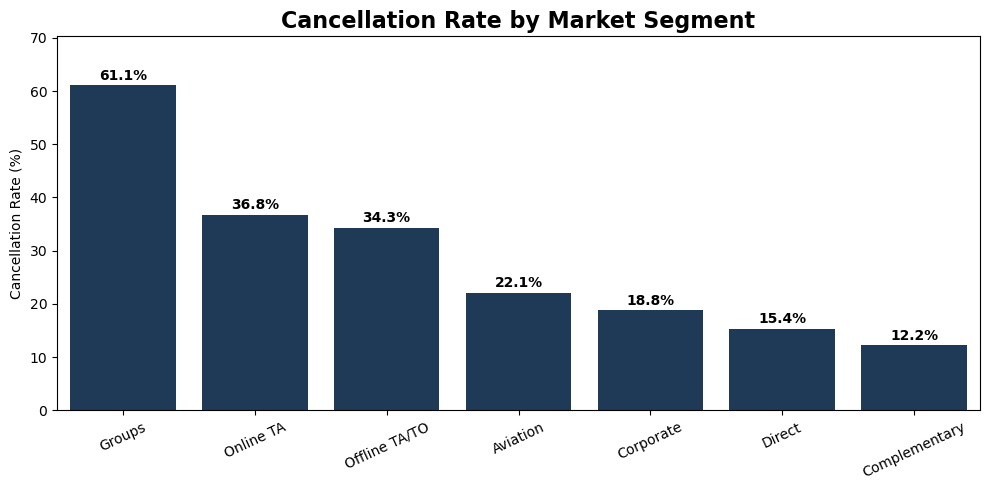

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=market_plot,
    x="market_segment",
    y="is_canceled",
    color="#2F5D62"
)

plt.title(
    "Cancellation Rate by Market Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Cancellation Rate (%)")

plt.xticks(rotation=25)

for i, value in enumerate(market_plot["is_canceled"]):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.ylim(0, market_plot["is_canceled"].max()*1.15)

plt.tight_layout()

plt.show()

**Key Findings**

Excluding the two "Unknown" bookings (in order to have a cleaner chart), the Groups segment has the highest cancellation rate (61.1%), followed by Online TA (36.8%), which show already a big difference between them. This suggests that booking channel and customer segment may be important predictors of cancellations. Revenue Manager should take a close look at the market segment prior to deciding commercial promotions.

**1.3. Does the deposit type influence booking cancellation rates?**

This analysis compares cancellation rates across the different deposit types.

In [123]:
deposit_cancel = (
    df_clean.groupby("deposit_type")["is_canceled"]
    .mean()
    .reset_index()
)

deposit_cancel["is_canceled"] *= 100

deposit_cancel = deposit_cancel.sort_values(
    by="is_canceled",
    ascending=False
)

deposit_cancel

,deposit_type,is_canceled
1,Non Refund,99.362446
0,No Deposit,28.401987
2,Refundable,22.222222


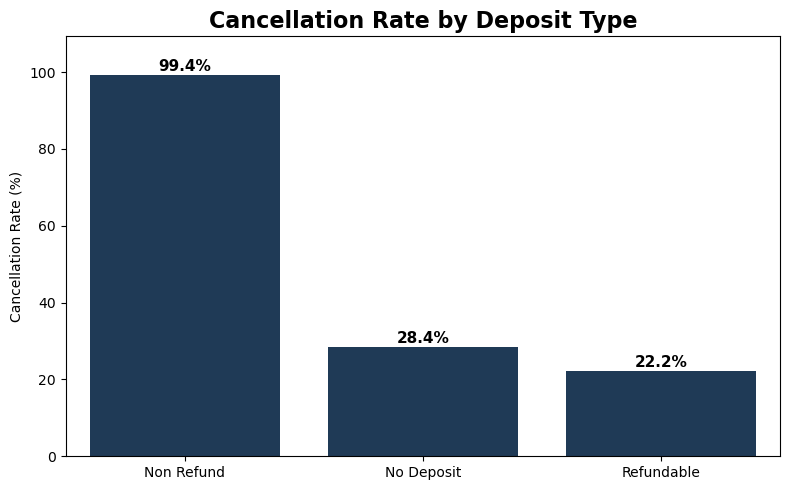

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=deposit_cancel,
    x="deposit_type",
    y="is_canceled",
    color="#2F5D62"
)

plt.title(
    "Cancellation Rate by Deposit Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(deposit_cancel["is_canceled"]):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(0, deposit_cancel["is_canceled"].max()*1.10)

plt.tight_layout()

plt.show()

Bookings with a Non Refund deposit have the highest cancellation rate (99.4%), while No Deposit and Refundable bookings show much lower rates.

This indicates that deposit policy is strongly related to cancellations.

**Deposit Type: Additional Investigation**

The Non Refund deposit type showed an unusually high cancellation rate (99.4%), which is unexpected in a real hotel environment, where non-refundable bookings are generally less likely to be cancelled.

To better understand this result, an additional analysis was performed by combining market segment and deposit type.


In [125]:
df_clean["deposit_type"].value_counts()

deposit_type
No Deposit    104461
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [126]:
pd.crosstab(
    df_clean["deposit_type"],
    df_clean["is_canceled"],
    margins=True
)

is_canceled,0,1,All
deposit_type,,,
No Deposit,74792,29669,104461
Non Refund,93,14494,14587
Refundable,126,36,162
All,75011,44199,119210


In [127]:
pd.crosstab(
    df_clean["deposit_type"],
    df_clean["reservation_status"]
)

reservation_status,Canceled,Check-Out,No-Show
deposit_type,,,
No Deposit,28498,74792,1171
Non Refund,14460,93,34
Refundable,35,126,1


In [128]:
df_clean[df_clean["deposit_type"] == "Non Refund"][
    ["is_canceled", "reservation_status", "adr", "market_segment"]
]

,is_canceled,reservation_status,adr,market_segment
2133,1,Canceled,36.05,Groups
2134,1,Canceled,36.05,Groups
2135,1,Canceled,36.05,Groups
2136,1,Canceled,36.05,Groups
2141,1,Canceled,36.05,Groups
...,...,...,...,...
95424,0,Check-Out,106.00,Corporate
95936,0,Check-Out,106.00,Corporate
96193,0,Check-Out,72.25,Offline TA/TO
96232,0,Check-Out,83.83,Online TA


In [129]:
df_clean[df_clean["deposit_type"] == "Non Refund"]["market_segment"].value_counts()

market_segment
Groups           9172
Offline TA/TO    5006
Corporate         334
Online TA          56
Direct             19
Name: count, dtype: int64

In [130]:
pd.crosstab(
    [df_clean["market_segment"], df_clean["deposit_type"]],
    df_clean["is_canceled"],
    normalize="index"
).round(3) * 100

is_canceled                     0      1
market_segment deposit_type             
Aviation       No Deposit    77.9   22.1
Complementary  No Deposit    87.8   12.2
Corporate      No Deposit    86.3   13.7
               Non Refund     6.6   93.4
               Refundable    75.0   25.0
Direct         No Deposit    84.7   15.3
               Non Refund    15.8   84.2
               Refundable    66.7   33.3
Groups         No Deposit    71.7   28.3
               Non Refund     0.7   99.3
               Refundable    90.0   10.0
Offline TA/TO  No Deposit    82.8   17.2
               Non Refund     0.1   99.9
               Refundable    50.0   50.0
Online TA      No Deposit    63.3   36.7
               Non Refund     5.4   94.6
               Refundable     0.0  100.0
Unknown        No Deposit     0.0  100.0

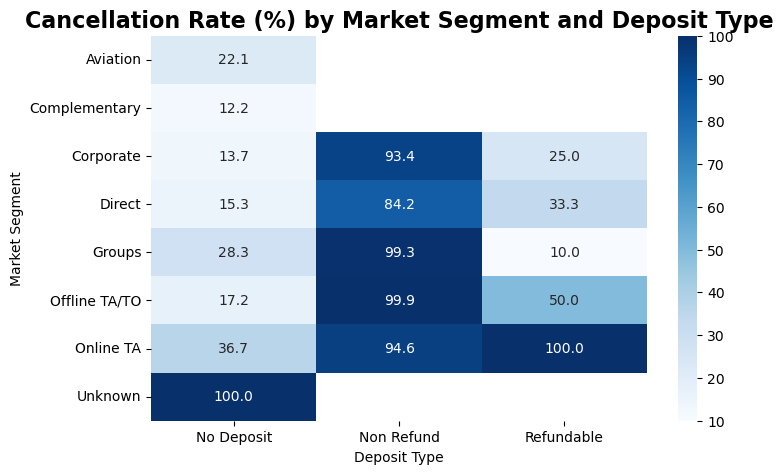

In [131]:
heatmap_data = (
    df_clean.groupby(["market_segment", "deposit_type"])["is_canceled"]
    .mean()
    .unstack()
    * 100
)

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Cancellation Rate (%) by Market Segment and Deposit Type",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Deposit Type")
plt.ylabel("Market Segment")

plt.show()

**Key Findings**
The results show that this pattern is consistent across most market segments, especially Groups and Offline TA/TO, where almost all Non Refund bookings were cancelled. This suggests that the relationship may be specific to this dataset rather than representing a typical booking beahivour.

This finding will be considered when selecting the final variables for the predictive model.

**1.4. Does lead time influence booking cancellation rates?**

This analysis explores whether bookings made further in advance are more likely to be cancelled.

In [132]:
bins = [-1, 7, 30, 90, 180, df_clean["lead_time"].max()]

labels = [
    "0-7",
    "8-30",
    "31-90",
    "91-180",
    "180+"
]

df_clean["lead_time_group"] = pd.cut(
    df_clean["lead_time"],
    bins=bins,
    labels=labels
)

In [133]:
lead_cancel = (
    df_clean.groupby("lead_time_group", observed=False)["is_canceled"]
    .mean()
    .reset_index()
)

lead_cancel["is_canceled"] *= 100

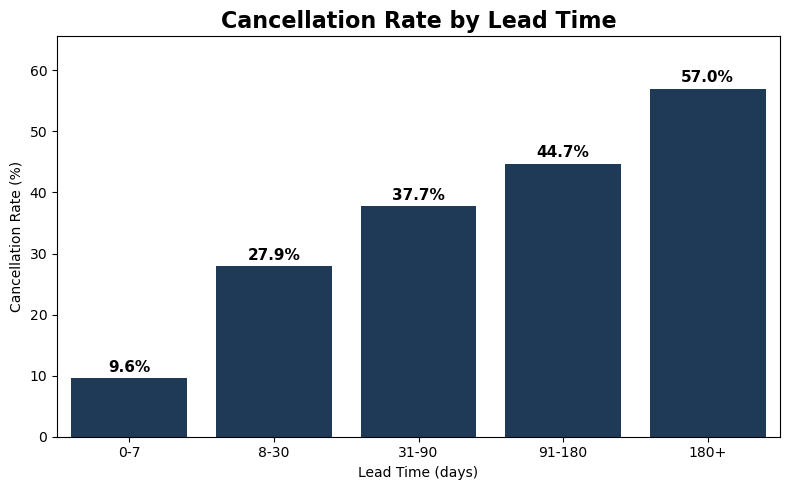

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=lead_cancel,
    x="lead_time_group",
    y="is_canceled",
    color="#2F5D62"
)

plt.title(
    "Cancellation Rate by Lead Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Lead Time (days)")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(lead_cancel["is_canceled"]):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(0, lead_cancel["is_canceled"].max()*1.15)

plt.tight_layout()

plt.show()

**Key Findings**

The results show a clear relationship between lead time and booking cancellations. The longer the lead time, the higher the cancellation rate, increasing from 9.6% for bookings made within 7 days to 57.0% for bookings made more than 180 days in advance.

**1.5. Does customer type influence booking cancellation rates?

This analysis explores whether customer type is associated with different cancellation rates.

In [135]:
customer_cancel = (
    df_clean.groupby("customer_type")["is_canceled"]
    .mean()
    .reset_index()
)

customer_cancel["is_canceled"] *= 100

customer_cancel = customer_cancel.sort_values(
    by="is_canceled",
    ascending=False
)

customer_cancel

,customer_type,is_canceled
2,Transient,40.786356
0,Contract,30.992141
3,Transient-Party,25.450415
1,Group,10.104530


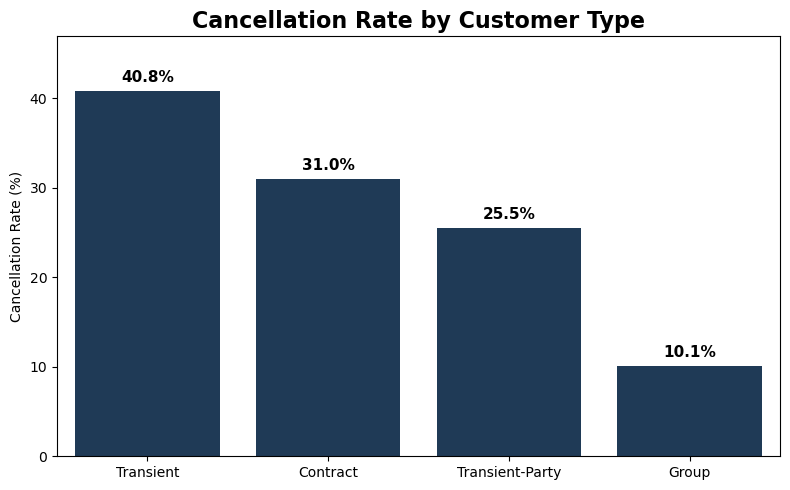

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=customer_cancel,
    x="customer_type",
    y="is_canceled",
    color="#2F5D62"
)

plt.title(
    "Cancellation Rate by Customer Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(customer_cancel["is_canceled"]):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(0, customer_cancel["is_canceled"].max()*1.15)

plt.tight_layout()

plt.show()

In [137]:
df_clean["customer_type"].value_counts()

customer_type
Transient          89476
Transient-Party    25088
Contract            4072
Group                574
Name: count, dtype: int64

In [138]:
pd.crosstab(
    df_clean["market_segment"],
    df_clean["customer_type"]
)

customer_type,Contract,Group,Transient,Transient-Party
market_segment,,,,
Aviation,0,2,216,17
Complementary,2,6,688,32
Corporate,22,28,3569,1663
Direct,14,134,11317,1117
Groups,735,16,8423,10617
Offline TA/TO,1816,210,14027,8129
Online TA,1483,178,51236,3511
Unknown,0,0,0,2


**Key Findings**

Transient customers show the highest cancellation rate (40.8%), while Group customers have the lowest (10.1%). This suggests that customer type is associated with different booking behaviours and may contribute to predicting cancellations.

When we noticed that Group only had a 10.1% of cancellation rate, we wanted to check its relationship to the market segment, since it shows just the opposite.

Although both variables contain categories related to groups, "market_segment" and "customer_type" describe different aspects of the booking.

"Market_segment" represents the commercial source of the reservation, while "customer_type" describes the customer profile. Therefore, both variables provide different information and will be considered independently.


#### 2. Understanding Customer Behaviour

This section explores customer characteristics that may influence booking cancellations.

Understanding customer behaviour can help Revenue Managers identify more reliable guests and improve commercial decision-making.

**2.1. Are repeated guests less likely to cancel?**

This analysis compares cancellation rates between new and repeated guests.

In [139]:
repeated_cancel = (
    df_clean.groupby("is_repeated_guest")["is_canceled"]
    .mean()
    .reset_index()
)

repeated_cancel["is_canceled"] *= 100

repeated_cancel["is_repeated_guest"] = (
    repeated_cancel["is_repeated_guest"]
    .map({0: "New Guest", 1: "Repeated Guest"})
)

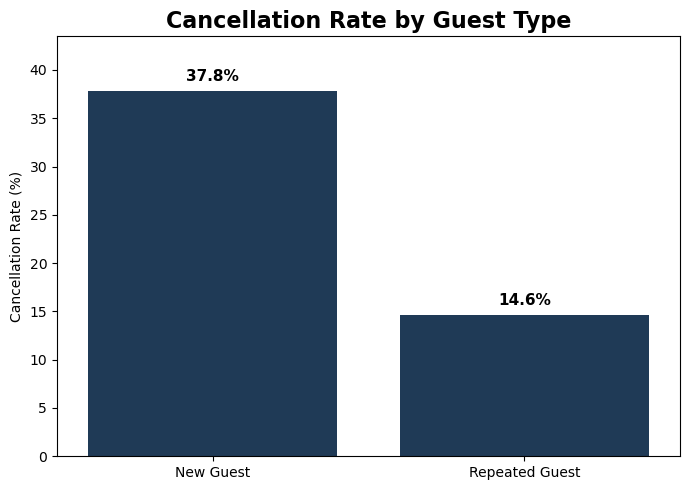

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=repeated_cancel,
    x="is_repeated_guest",
    y="is_canceled",
    color="#2F5D62"
)

plt.title(
    "Cancellation Rate by Guest Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(repeated_cancel["is_canceled"]):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(0, repeated_cancel["is_canceled"].max()*1.15)

plt.tight_layout()

plt.show()

In [141]:
df_clean["is_repeated_guest"].value_counts()

is_repeated_guest
0    115455
1      3755
Name: count, dtype: int64

**Key Findings**

Repeated guests are much less likely to cancel their bookings than new guests (14.6% vs 37.8%). This suggests that guest loyalty is associated with more reliable booking behaviour.

Although repeated guests represent only 3.1% of all customers, they show a substantially lower cancellation rate, suggesting that guest loyalty is associated with more reliable booking behaviour.

**2.2. Do previous cancellations increase future cancellation risk?**

This analysis explores whether guests with previous cancellations are more likely to cancel again.

In [142]:
df["previous_cancellations"].value_counts()

previous_cancellations
0     112906
1       6051
2        116
3         65
24        48
11        35
4         31
26        26
25        25
6         22
19        19
5         19
14        14
13        12
21         1
Name: count, dtype: int64

In [143]:
df_clean["previous_cancel_group"] = np.where(
    df_clean["previous_cancellations"] == 0,
    "No Previous",
    "Previous Cancellation"
)

In [144]:
previous_cancel = (
    df_clean.groupby("previous_cancel_group")["is_canceled"]
    .mean()
    .reset_index()
)

previous_cancel["is_canceled"] *= 100

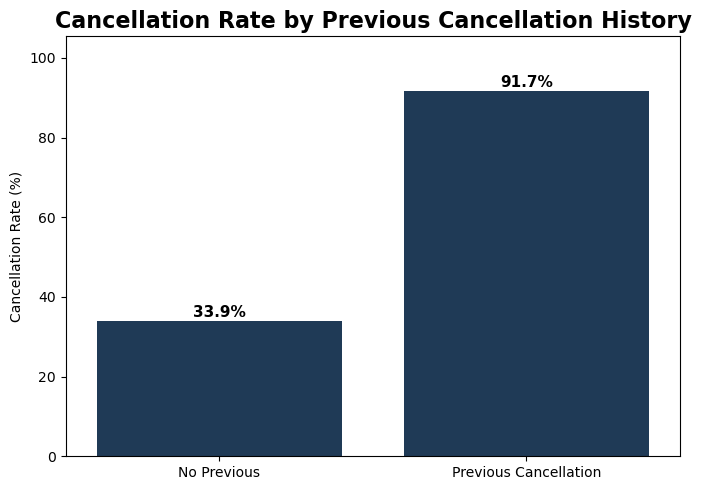

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=previous_cancel,
    x="previous_cancel_group",
    y="is_canceled",
    color="#2F5D62"
)

plt.title(
    "Cancellation Rate by Previous Cancellation History",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(previous_cancel["is_canceled"]):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(0, previous_cancel["is_canceled"].max()*1.15)

plt.tight_layout()

plt.show()

In [146]:
df_clean["previous_cancel_group"].value_counts()

previous_cancel_group
No Previous              112731
Previous Cancellation      6479
Name: count, dtype: int64

**Key Findings**

Since there are many values in this variable, we decided to divide the data amongst: previous cancellations? Yes or No.

Guests with at least one previous cancellation show a much higher cancellation rate (91.7%) than guests with no previous cancellations (33.9%). Although they represent only 5.4% of all bookings, previous cancellation history appears to be a strong indicator of future cancellation behaviour.

**2.3. Do special requests relate to booking canellations?**

This analysis explores whether the number of special requests is associated with booking cancellations.

In [147]:
df_clean["total_of_special_requests"].value_counts()

total_of_special_requests
0    70201
1    33183
2    12952
3     2494
4      340
5       40
Name: count, dtype: int64

In [148]:
special_cancel = (
    df_clean.groupby("total_of_special_requests")["is_canceled"]
    .mean()
    .reset_index()
)

special_cancel["is_canceled"] *= 100

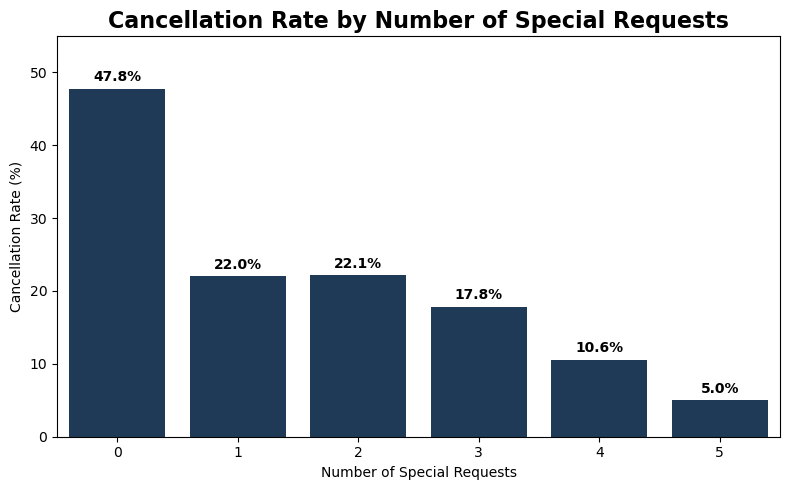

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=special_cancel,
    x="total_of_special_requests",
    y="is_canceled",
    color="#2F5D62"
)

plt.title(
    "Cancellation Rate by Number of Special Requests",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Special Requests")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(special_cancel["is_canceled"]):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.ylim(0, special_cancel["is_canceled"].max()*1.15)

plt.tight_layout()

plt.show()

**Key Findings**

Guests with no special requests have the highest cancellation rate (47.8%). Overall, the results show that the more special requests a guest makes, the lower the cancellation rate, suggesting a stronger commitment to the booking.

#### **EDA Summary**

The exploratory analysis identified several booking characteristics associated with cancellation behaviour.

The main findings are:

- **City Hotels** show higher cancellation rates than Resort Hotels.
- **Market segment** has a strong influence on cancellations, with **Groups** and **Online TA** showing the highest rates.
- **Lead time** is strongly related to cancellations, with bookings made further in advance being more likely to cancel.
- **Repeated guests** are considerably less likely to cancel than new guests.
- Guests with **previous cancellations** show a very high probability of cancelling again.
- Guests with **more special requests** tend to be more committed to their bookings and cancel less frequently.
- The **deposit type** showed an unusually strong relationship with cancellations and will be further evaluated before building the predictive model.

Overall, these findings provide valuable business insights and identify the variables that are most likely to contribute to predicting booking cancellations.

The next stage of the project is to build a Machine Learning model to evaluate whether these patterns can accurately predict booking cancellations. The model will also identify which variables contribute most to the predictions.

### 4. Machine Learning Models

Once we are done with the EDA, we will proceed with the feature engineering to prepare the dataset for our Machine Learning Model.



In [150]:
df_clean.to_csv("clean_hotel_booking.csv", index = False)

#### 4.1. Train Test Split

We define the features ("X") and the target ("y") of the model.

To improve the usability of the final application, the "agent" and "company" variables were replaced by two binary features ("has_agent" and "has_company"). Although this slightly reduced the model's performance, the impact was minimal while making the application considerably more practical for real-world use. Since both variables were identifiers rather than ordinal numerical values, the binary representation also provides a more meaningful feature for the model.

Several variables were removed before training the model. "reservation_status" and "reservation_status_date" were excluded because they contain information about the final outcome of the booking, which would introduce data leakage. We also removed "assigned_room_type", "booking_changes" and "days_in_waiting_list", as these variables are not available at the time the booking is created. Finally, "lead_time_group" and "previous_cancel_group" were excluded because they were engineered only for the exploratory analysis and duplicate information already contained in the original variables.

In [151]:
df_clean["has_agent"] = (
    df_clean["agent"] != 0
).astype(int)

df_clean["has_company"] = (
    df_clean["company"] != 0
).astype(int)

In [152]:
X = df_clean.drop(columns = [
    "is_canceled", 
    "reservation_status", 
    "reservation_status_date", 
    "lead_time_group", 
    "previous_cancel_group", 
    "assigned_room_type", 
    "booking_changes", 
    "days_in_waiting_list", 
    "arrival_date_year", 
    "arrival_date_week_number",
    "agent",
    "company"
    ])

y = df_clean["is_canceled"]

In [153]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 17, stratify = y)

We separate the features into numeric and categorical columns in order to treat each one of them in a different way.

In [154]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95368 entries, 38703 to 43832
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           95368 non-null  object 
 1   lead_time                       95368 non-null  int64  
 2   arrival_date_month              95368 non-null  object 
 3   arrival_date_day_of_month       95368 non-null  int64  
 4   stays_in_weekend_nights         95368 non-null  int64  
 5   stays_in_week_nights            95368 non-null  int64  
 6   adults                          95368 non-null  int64  
 7   children                        95368 non-null  int64  
 8   babies                          95368 non-null  int64  
 9   meal                            95368 non-null  object 
 10  country                         95368 non-null  object 
 11  market_segment                  95368 non-null  object 
 12  distribution_channel            9

In [155]:
numeric_features = X_train.select_dtypes(include = ["int64", "float64"]).columns.tolist()

categorical_features = X_train.select_dtypes(include = ["object", "category"]).columns.tolist()

In [156]:
numeric_features

['lead_time',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'has_agent',
 'has_company']

In [157]:
categorical_features

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'deposit_type',
 'customer_type']

#### 4.2. Preprocessing Pipeline

We prepare the categorical and numeric pipelines for both models we are testing.

In [158]:
# Logistic Regression Pipelines:

numeric_lr_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

lr_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_lr_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [159]:
# Random Forest Pipeline (we use the same categorical pipeline than in Logistic Regression)

numeric_pipeline = "passthrough"

preprocessor = ColumnTransformer(transformers = [
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

#### 4.3. Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

Logistic Regression is used as a baseline model because it is simple, fast and highly interpretable. Its performance provides a useful benchmark to evaluate whether a more complex model, such as Random Forest, offers a meaningful improvement.

In [160]:
logistic = LogisticRegression(
    random_state=17,
    max_iter=2000
)

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("model", logistic)
    ]
)

lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [161]:
y_pred_lr = lr_pipeline.predict(X_test)

y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

In [162]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86     15002
           1       0.81      0.64      0.71      8840

    accuracy                           0.81     23842
   macro avg       0.81      0.78      0.79     23842
weighted avg       0.81      0.81      0.81     23842



In [163]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f"ROC-AUC: {roc_auc_lr:.3f}")
print(f"Accuracy: {accuracy_lr:.3f}")

ROC-AUC: 0.888
Accuracy: 0.811


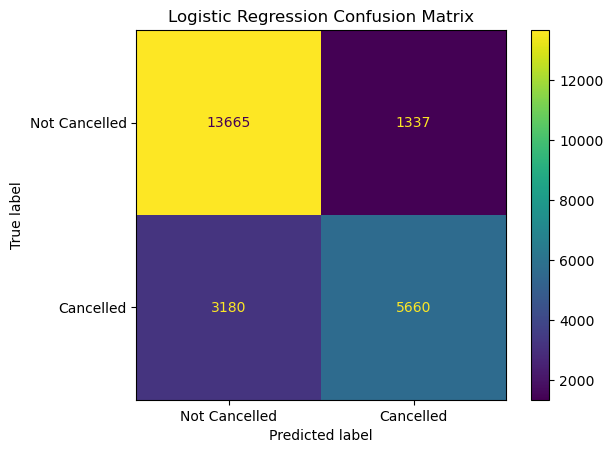

In [164]:
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Cancelled", "Cancelled"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

**Key Fidings**

The Logistic Regression model achieved an overall accuracy of 81%. It correctly identified 64% of cancelled bookings, while maintaining a precision of 81% for the cancellation class.

These results show that the model performs well regarding accuracy metrics but it fails to identify cancelled reservations, only 64%, showing up to 3180 False Negatives.

#### 4.4. Random Forest Model

Once we tested the Logistic Regression, we decided to try Random Forest, because it can capture complex and non-linear relationships between booking characteristics.

It also works well with numerical and encoded categorical variables, does not require feature scaling (this is why we had different numeric pipelines for each model), and allows us to evaluate feature importance.

In [165]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=17,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest)
    ])

In [166]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [167]:
y_pred_rf = rf_pipeline.predict(X_test)

y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [168]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91     15002
           1       0.88      0.80      0.84      8840

    accuracy                           0.88     23842
   macro avg       0.88      0.87      0.87     23842
weighted avg       0.88      0.88      0.88     23842



In [169]:
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"ROC-AUC: {roc_auc_rf:.3f}")
print(f"Accuracy: {accuracy_rf:.3f}")


ROC-AUC: 0.953
Accuracy: 0.884


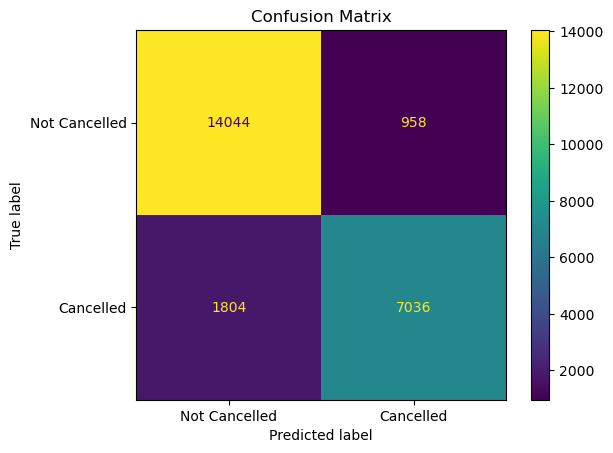

In [170]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Cancelled", "Cancelled"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

**Key Findings**

The Random Forest model achieved an overall accuracy of 88%. It correctly identified 80% of cancelled bookings, while maintaining a precision of 88% for the cancellation class.

These results show that the model performs well overall, although some cancelled bookings are still incorrectly classified as not cancelled.

#### 4.5. Model Comparison

We compare both models to see which one outperforms.

In [171]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf
    ],
    "Precision": [
        precision_lr,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_rf
    ],
    "F1 Score": [
        f1_lr,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf
    ]
})

comparison = comparison.round(3)
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.811,0.809,0.640,0.715,0.888
1,Random Forest,0.884,0.880,0.796,0.836,0.953


**Key Finding**

Logistic Regression was used as a baseline because it is a simple and interpretable classification model.

Random Forest achieved better results across the main evaluation metrics, especially recall (with 80% VS 64%) and ROC-AUC (95% VS 89%). Since identifying cancelled bookings is the main objective of this project, Random Forest was selected as the final model for the Booking Risk Analyzer.

#### 4.6. Features Importance

It is important to understand which features contribute to the model performance.

In [172]:
X.columns.tolist()

['hotel',
 'lead_time',
 'arrival_date_month',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'deposit_type',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'has_agent',
 'has_company']

In [173]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

In [174]:

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_pipeline.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,num__lead_time,0.125966
10,num__adr,0.090016
227,cat__deposit_type_Non Refund,0.071810
1,num__arrival_date_day_of_month,0.068503
163,cat__country_PRT,0.065174
226,cat__deposit_type_No Deposit,0.057752
12,num__total_of_special_requests,0.056609
3,num__stays_in_week_nights,0.044341
8,num__previous_cancellations,0.029552
2,num__stays_in_weekend_nights,0.028599


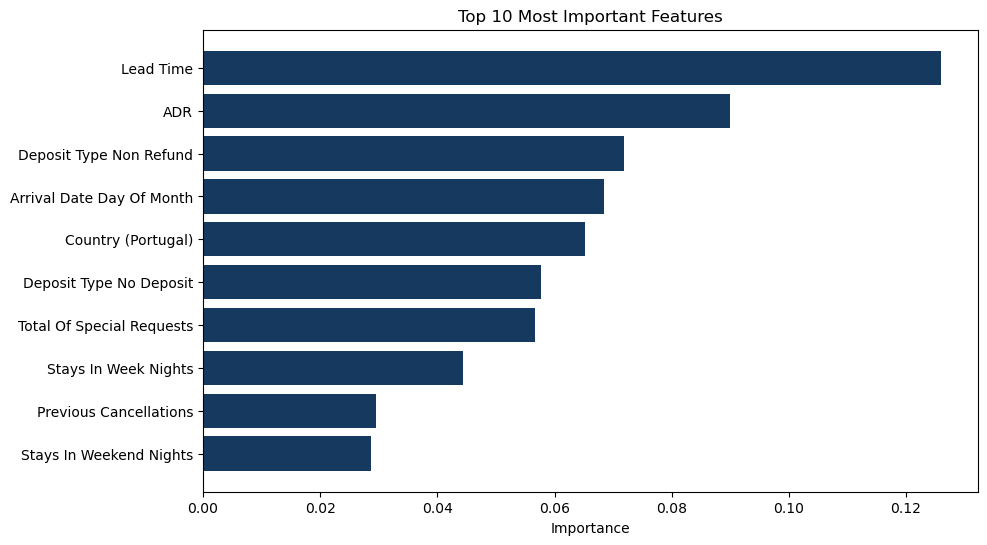

In [ ]:
top_features = feature_importance.head(10).copy()

top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
    .str.replace("Adr", "ADR", regex=False)
    .str.replace("Country Prt", "Country (Portugal)", regex=False)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color="#2F5D62"
)

plt.xlabel("Importance")
plt.ylabel("")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

We investigated further the ADR variable, since it has such a high importance.

In [176]:
cancellation_by_adr = (
    df_clean.groupby("is_canceled")["adr"]
    .median()
)

cancellation_by_adr

is_canceled
0    92.7
1    96.3
Name: adr, dtype: float64

/var/folders/c0/b40y5t4n3mn_4jcw8gjbz1zm0000gn/T/ipykernel_4686/3848835375.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


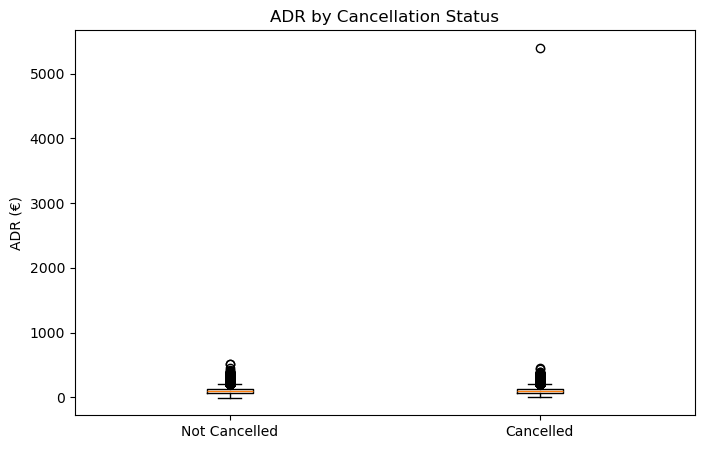

In [177]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        df_clean[df_clean["is_canceled"] == 0]["adr"],
        df_clean[df_clean["is_canceled"] == 1]["adr"]
    ],
    labels=["Not Cancelled", "Cancelled"]
)

plt.ylabel("ADR (€)")
plt.title("ADR by Cancellation Status")

plt.show()

**Key Findings**

Lead Time is the most important predictor of booking cancellations, confirming the trend observed during the EDA.

Lead Time, Deposit Type, Previous Cancellations and Total Special Requests were among the most important predictors, reinforcing the relationships previously observed.

Other variables, such as ADR and Country, also contributed to the model. However, their individual effect was not as evident during the exploratory analysis, suggesting that the model uses them in combination with other booking characteristics to improve its predictions.

### 5. Business Interpretation

Thanks to these findings we can construct business interpretations in order to assist Revenue Managers take decissions. 

**Recommendation 1**

Bookings made several months in advance could be monitored more closely, as they present a higher cancellation risk. Hotel may use reminder emails or confirmation requests before the arrival date.

**Recommendation 2**

Guests with a history of previous cancellations could be flagged as high-risk customers. Hotel may consider requesting additional confirmation or applying different booking policies.

**Recommendation 3**

Repeated guests show much lower cancellation rates. Hotel should continue investing in loyalty programms, as returning customers appear to be more reliable.

**Recommendation 4**

Guests with several special requests appear more committed to their reservation. Therefore, special requests may be considered as an indicator of booking commitment.



### 6. Booking Risk Analyzer
The Booking Risk Analyzer can help hotels identify reservations with a higher probability of cancellation before the arrival date.

This information may support operational decisions such as overbooking management, customer communication, commercial promotions and deposit policies.

Rather than replacing human decisions, the model provides an additional decision-support tool for hotel managers.


**Exporting the model**

The final Random Forest Pipeline is exported using pickel. Since the preprocessing and the classifier are combined into a single pipeline, only one file is required to be used in our Streamlit application.

In [178]:
with open("models/random_forest_pipeline.pkl", "wb") as file:
    pickle.dump(rf_pipeline, file)

In [179]:
# Testing the model

with open("models/random_forest_pipeline.pkl", "rb") as file:
    model = pickle.load(file)

In [180]:
model.predict(X_test.head())

array([0, 0, 1, 1, 1])

In [181]:
model.feature_names_in_

array(['hotel', 'lead_time', 'arrival_date_month',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'deposit_type', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'has_agent', 'has_company'], dtype=object)

### 7. Limitations and Future Improvements

This project was developed using historical booking data (bookings due to arrive between July 1st 2015 and August 31st 2017) from two hotels in Portugal, a Resort and a City Hotel.

Future improvements could include:

- Testing additional machine learning models such as XGBoost.
- Hyperparameter tuning to further improve performance.
- Optimising the decision threshold according to business objectives.
- Using more recent hotel booking data.
- Compare with competitive set.
- The "country" variable was identified as one of the most important predictors. However, in hotel management systems, missing country information may sometimes be replaced by the hotel's home country. If this occurred in the original dataset, the importance of this variable could be overestimated. Further validation of the data collection process would be recommended before deploying the model in a real environment.

In [182]:
df_clean["country"].nunique()

178

In [183]:
df_clean["previous_cancellations"].max()

26

In [184]:
df_clean["previous_bookings_not_canceled"].max()

72

In [185]:
df_clean["required_car_parking_spaces"].max()

8

In [186]:
df_clean["total_of_special_requests"].max()

5

In [187]:
df_clean["agent"].max()

535

In [188]:
df_clean["company"].max()

543